In [67]:
import pandas as pd
import numpy as np
import sys
import os
from netCDF4 import Dataset, date2num
import glob
import scipy.io
import tqdm
import xarray as xr
import os
import warnings
import matplotlib.pyplot as plt
import  scipy as sc
from pydsstools.heclib.dss import HecDss
from scipy.stats import pearsonr
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from cartopy.feature import ShapelyFeature
from cartopy.io.shapereader import Reader
from sklearn import metrics
import seaborn as sns
import spotpy
warnings.filterwarnings('ignore')

In [68]:
sys.version

'3.9.10 | packaged by conda-forge | (main, Feb  1 2022, 21:22:07) [MSC v.1929 64 bit (AMD64)]'

In [69]:
from osgeo import gdal, ogr
import os
#import gdalconst
import matplotlib.pyplot as plt
import tqdm
import shapely
from shapely.geometry import MultiPolygon, Point
from scipy.interpolate import griddata
from datetime import datetime
import glob
import os, shutil
from scipy import stats
import urllib.request
import time
from shapely.geometry.multipolygon import MultiPolygon
from shapely.geometry.polygon import Polygon
from shapely import wkt
from osgeo.gdalnumeric import *
from osgeo.gdalconst import *
from pandas.io.json import json_normalize
gdal.SetConfigOption("GDALWARP_IGNORE_BAD_CUTLINE", "YES")

In [70]:
def plot_figure_shp(shp, array, cmap, vmax, vmin, label, ax, label_figure,title,extent):
        """Plotea un shapefile con un range de valores según un array de entrada.
        Entradas:
        ---------
        shp:            Fichero en formato shp
        array:          Valores que se desa representar dentro de cada una de las entidades del shape
        cmap:           leyenda de colores con la que se desea representar la colorbar
        vmax, vmin:      valor máximo y mínimo de la colorbar
        label:           etiqueta de la colorbard
        ax:              eje de la figura donde se desea plotear la figura
        labels_figure:   título de la figura para cada uno de los subplots  
        title:           título de la figura general
        extent:           límites de la extensión que se quiere plotear"""

        import cartopy.crs as ccrs
        import cartopy.io.shapereader as shpreader
        import matplotlib.pyplot as plt
        import matplotlib as mpl
        import numpy as np

        shp = shpreader.Reader(shp)
        cmap = cmap
        norm = mpl.colors.Normalize(vmin, vmax)
        dfSingle= norm(array.values).data
        n=0
        for record, state in zip(shp.records(), shp.geometries()):
            name = record.attributes['name']
            num_users = array.loc[str(name)]
            colorNormalized = dfSingle[int(n)]
            ax.add_geometries([state], ccrs.PlateCarree(),facecolor=cmap(colorNormalized),edgecolor='black')
            n=n+1
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.set_title(label_figure, fontsize=15)
        sm = plt.cm.ScalarMappable(cmap=cmap)
        sm._A = [vmin,vmax]
        fig.colorbar(sm,label=label,ax=ax,orientation='horizontal',pad=0.1)
        fig.suptitle(title, fontsize=16)    

# Configuración del modelo

In [71]:
from funciones_HMS import *

In [72]:
Path_model = 'E:/TUNEZ/05_Model/Oued_Mellah_CAL/'
Path_model = 'E:/TUNEZ/Modelos_Nuevos/Oued_Mellah_CAL/'
file_hms = 'Oued_Mellah_Python.hms'
file_gage = 'Oued_Mellah_Python.gage'
file_basin = 'Oued_Mellah_SED.basin'
file_run= 'Oued_Mellah_Python.run'

In [73]:
names_basin=read_basin(Path_model, file_basin)
names_basin

['Oued_Mellah_SED']

In [74]:
names_stations = read_gages(Path_model, file_gage)

In [75]:
names_sbasin= read_subbasin(Path_model, file_basin)

In [76]:
names_control = read_control(Path_model, file_hms)

In [77]:
names_control

['Control_CAL', 'Control_Extremal']

In [78]:
names_run = Read_run(Path_model, file_run)
names_run

['CALSED']

In [79]:
# NOMBRES DE FICHEROS -------------------------------------------------------------------------------------------------------------------------------------------------
Path_model = 'E:/TUNEZ/Modelos_Nuevos/Oued_Mellah_CAL/'
path_rain = 'E:/TUNEZ/01_Datos_Climaticos/Reconstruccion/Precipitacion_centroides_OK_NEW_2.csv' # El fichero debe contener una columna con fecha (index) y los datos de lluvias de estaciónes en cada columna 
name_model = 'Oued_Mellah_Python' # Nombre del fichero .hms sin la extensión
name_basin = 'Oued_Mellah_SED' # Igual al arrojado en namesbasin
name_control = 'Campiazo' # Igual al arrojado en namecontrol
file_dss = 'Oued_Mellah_Python.dss' # Nombre de fichero donde se almacenan las lluvias

# DEFINICIÓN DEL TIEMPO E INTERVALOS PARA LLENAR LOS DATOS DE LLUVIAS EN EL PROGRAMA -------------------------------------------------------------------------------------------------
#Nota: Si el control ya esta generado en el programa, no es necesario llenar estos datos
Time_interval = '1DAY' #(1MIN, 2MIN, 3MIN,4MIN,5MIN,6MIN,10MIN,...,1HOUR,....1DAY) dependiendo de la resolución de los datos se puede variar
Start_Time = '1 January 1979, 00:00' # Fecha de inicio del control
End_Time = '31 December 2018, 00:00' # Fecha de fin del control
name_control = 'Control_Prueba' # Nombre del nuevo modulo de control que se quiere generar

# DEFINICIÓN DEL TIEMPO E INTERVALOS PARA EL MODULO DEL CONTROL DEL PROGRAMA ---------------------------------------------------------------------------------------------------------
Start_Time_c = '1 January 1981' # un intervalo antes al inicio de la lluvia (datos diarios) o el mismo dia de inicio del evento si el mismo no supera un dia 
End_Time_c = '31 December 1990'
Time_interval_c ='60' # Se debe ingresar en minutos, en este caso se usa un dia = 60*24 = 1440

#Name_run = 'Run' # en caso de generar una nueva corrida se asigna el nombre que prefiera el usuario

In [17]:
Centroides = pd.read_csv('E:/TUNEZ/GIS/Centroides.csv',index_col=0)

In [70]:
names_stations =  Centroides.name.values

In [71]:
generate_gage(name_model, names_stations, Time_interval, Path_model, Start_Time, End_Time, file_dss)

################### El fichero .gage fue modificado satisfactoriamente ###################


In [72]:
fill_gage(names_stations, path_rain, Time_interval, Path_model, file_dss, Start_Time, End_Time)

100%|██████████████████████████████████████████████████████████████████████████████████| 31/31 [00:02<00:00, 11.10it/s]

################### Se ha modificado el fichero .dss satisfactoriamente y se han llenado los datos de lluvia ###############################


##### <span style="color:#33A5FF">Utilizar estas dos funciones solo si se quieren crear automáticamente los modulos meteorológicos a partir de las subcuencas del modelo, si los modulos ya están creados no es necesario ejecutarlas.</span>

In [73]:
ET_Table = pd.read_csv('E:/TUNEZ/01_Datos_Climaticos/Reconstruccion/ETP_Centroides_2.csv',index_col=0,decimal=',',delimiter=';')
name_met = 'Salva_2'

In [74]:
ET_Table

,1,Factor_1,2,Factor_2,3,Factor_3,4,Factor_4,5,Factor_5,...,8,Factor_8,9,Factor_9,10,Factor_10,11,Factor_11,12,Factor_12
name,,,,,,,,,,,,,,,,,,,,,
Basin50,33.538575,2.4,42.903706,2.4,70.058287,2.4,92.764707,2.4,131.435018,2.4,...,154.602645,2.4,109.154556,2.4,76.938912,2.4,43.961137,2.4,32.778864,2.4
Basin49,33.827207,2.4,43.174221,2.4,70.317828,2.4,92.950654,2.4,131.384640,2.4,...,154.483249,2.4,109.304703,2.4,77.164504,2.4,44.253736,2.4,33.070341,2.4
Basin56,33.462654,2.4,43.047827,2.4,70.888636,2.4,94.287747,2.4,135.244697,2.4,...,160.153376,2.4,111.913416,2.4,78.204129,2.4,44.124827,2.4,32.643491,2.4
Basin55,35.194849,2.4,44.930169,2.4,73.307788,2.4,97.234852,2.4,138.348071,2.4,...,162.955891,2.4,114.693668,2.4,80.585440,2.4,46.071004,2.4,34.398146,2.4
Basin51,35.381813,2.4,45.010508,2.4,73.081128,2.4,96.627710,2.4,136.589764,2.4,...,160.465164,2.4,113.568089,2.4,80.149657,2.4,46.154224,2.4,34.607911,2.4
Basin64,33.667806,2.4,43.099532,2.4,70.495763,2.4,93.398506,2.4,132.802987,2.4,...,156.625642,2.4,110.265163,2.4,77.521910,2.4,44.178507,2.4,32.884636,2.4
Basin54,34.100728,2.4,43.514579,2.4,70.912644,2.4,93.727764,2.4,132.805507,2.4,...,156.529827,2.4,110.534441,2.4,77.890105,2.4,44.625658,2.4,33.322622,2.4
Basin48,33.416231,2.4,42.535852,2.4,69.045670,2.4,90.924539,2.4,127.896847,2.4,...,150.394196,2.4,106.866178,2.4,75.698547,2.4,43.634575,2.4,32.678408,2.4
Basin112,32.306578,2.4,41.457418,2.4,67.959635,2.4,89.944772,2.4,127.777268,2.4,...,150.861942,2.4,106.273132,2.4,74.778884,2.4,42.498271,2.4,31.543624,2.4


In [75]:
generate_met(name_met, names_sbasin,names_stations, Path_model, name_basin,Evapotranspiration=True,ET_Table=ET_Table)

################### Los ficheros .met fueron creados en la carpeta del proyecto satisfactoriamente ###############################


In [76]:
names_met =list()
import os
for file in os.listdir(Path_model):
    if file.endswith(".met"):
        names_met.append(file[:-4])

In [77]:
generate_hms(name_model, Path_model, names_met, file_dss, names_basin, names_control)

################### El fichero .hms fue modificado satisfactoriamente ###############################


##### <span style="color:#33A5FF">Utilizar estas funciónes solo si se quiere crear un control y una corrida nueva, en caso de que el control ya este creado en el programa no es necesario</span>

In [78]:
generate_control(name_model, Path_model, 'Control_CAL', Start_Time_c, End_Time_c, Time_interval_c)

################### El fichero .control fue creado satisfactoriamente ###############################


In [87]:
Name_run = 'Sim_1979_2005'

In [88]:
generate_run(Path_model, name_model, Name_run,'Salva_2', name_basin,'Period_Hist_1_hr')

################### El fichero .run fue creado satisfactoriamente ###############################


In [93]:
Generate_py(Path_model, name_model, [Name_run])

################### El fichero .py fue creado satisfactoriamente ###############################


In [94]:
# Con este modulo se corre el programa HEC HMS, para saber si la modelacion tuvo exito debe aparecer un 0 al final, en caso contrario aparece un -1
os.chdir('C:/Program Files/HEC/HEC-HMS/4.9/')
os.system('HEC-HMS.cmd -script '+Path_model+'scripts/compute_current.py')

0

In [80]:
Path_model      = 'E:/TUNEZ/Modelos_Nuevos/Oued_Mellah_CAL/'
Name_run =  'Sim_1979_2005'

fid = HecDss.Open(Path_model+Name_run+'.dss')
pn = '//JUNT7/FLOW/01JAN1979/1HOUR/RUN:SIM_1979_2005/'
ts = fid.read_ts(pn,window=('1979-01-01','2005-12-31'))
values = pd.DataFrame(ts.values)
times = np.array(ts.pytimes)
Q = pd.DataFrame(index= times, columns = ['flow'])
Q.loc[:,'flow'] = values.iloc[:,0].values

pn_s = '//JUNT7/SEDIMENT-OUT/01JAN1979/1HOUR/RUN:SIM_1979_2005/'
ts_SED = fid.read_ts(pn_s,window=('1979-01-01','2005-12-31'))
values = pd.DataFrame(ts_SED.values)
times = np.array(ts_SED.pytimes)
SED = pd.DataFrame(index= times, columns = ['Ton'])
SED.loc[:,'Ton'] = values.iloc[:,0].values.reshape(-1,1)
SED[SED>10000] = np.nan
SED[SED==-float('Inf')] = np.nan
SED[SED==float('Inf')] = np.nan
SED[SED<0] = np.nan

Q.resample('D').mean().to_csv('E:/TUNEZ/07_Cambio_Climatico/CAUDAL/Caudal_JUNT7_1979_2005_2.csv')
SED.resample('D').sum().to_csv('E:/TUNEZ/07_Cambio_Climatico/CAUDAL/SED_JUNT7_1979_2005_2.csv')

In [81]:
Path_model      = 'E:/TUNEZ/Modelos_Nuevos/Oued_Mellah_CAL/'
Name_run =  'Sim_1979_2005'

fid = HecDss.Open(Path_model+Name_run+'.dss')
pn = '//REACH3/FLOW/01JAN1979/1HOUR/RUN:SIM_1979_2005/'
ts = fid.read_ts(pn,window=('1979-01-01','2005-12-31'))
values = pd.DataFrame(ts.values)
times = np.array(ts.pytimes)
Q = pd.DataFrame(index= times, columns = ['flow'])
Q.loc[:,'flow'] = values.iloc[:,0].values

pn_s = '//REACH3/SEDIMENT-OUT/01JAN1979/1HOUR/RUN:SIM_1979_2005/'
ts_SED = fid.read_ts(pn_s,window=('1979-01-01','2005-12-31'))
values = pd.DataFrame(ts_SED.values)
times = np.array(ts_SED.pytimes)
SED = pd.DataFrame(index= times, columns = ['Ton'])
SED.loc[:,'Ton'] = values.iloc[:,0].values.reshape(-1,1)
SED[SED>10000] = np.nan
SED[SED==-float('Inf')] = np.nan
SED[SED==float('Inf')] = np.nan
SED[SED<0] = np.nan

Q.resample('D').mean().to_csv('E:/TUNEZ/07_Cambio_Climatico/CAUDAL/Caudal_REACH3_1979_2005_2.csv')
SED.resample('D').sum().to_csv('E:/TUNEZ/07_Cambio_Climatico/CAUDAL/SED_REACH3_1979_2005_2.csv')

In [82]:
Caudal = pd.DataFrame(index=pd.date_range(start = '1979-01-01 00:00:00', end='2005-12-31 23:00:00',freq = '1h'),columns=Centroides.name)

In [83]:
Path_model      = 'E:/TUNEZ/Modelos_Nuevos/Oued_Mellah_CAL/'
Name_run =  'Sim_1979_2005'
Caudal = pd.DataFrame(index=pd.date_range(start = '1979-01-01 00:00:00', end='2005-12-31 00:00:00',freq = '1h'),columns=Centroides.name)
Caudal_SED = pd.DataFrame(index=pd.date_range(start = '1979-01-01 00:00:00', end='2005-12-31 00:00:00',freq = '1h'),columns=Centroides.name)
fid = HecDss.Open(Path_model+Name_run+'.dss')

for i in tqdm.tqdm(Centroides.name):
    pn = '//'+i.upper()+'/FLOW/01JAN1979/1HOUR/RUN:SIM_1979_2005/'
    ts = fid.read_ts(pn,window=('1979-01-01','2005-12-31'))
    values = pd.DataFrame(ts.values)
    times = np.array(ts.pytimes)
    Q = pd.DataFrame(index= times, columns = ['flow'])
    Q.loc[:,'flow'] = values.iloc[:,0].values

    Caudal.loc[Q.index,i] = values.iloc[:,0].values

    pn_s = '//'+i.upper()+'/SEDIMENT LOAD/01JAN1979/1HOUR/RUN:SIM_1979_2005/'
    ts_SED = fid.read_ts(pn_s,window=('1979-01-01','2005-12-31'))
    values = pd.DataFrame(ts_SED.values)
    times = np.array(ts_SED.pytimes)
    SED = pd.DataFrame(index= times, columns = ['Ton'])
    SED.loc[:,'Ton'] = values.iloc[:,0].values.reshape(-1,1)
    SED[SED>10000] = np.nan
    SED[SED==-float('Inf')] = np.nan
    SED[SED==float('Inf')] = np.nan
    SED[SED<0] = np.nan
    Caudal_SED.loc[SED.index,i] = SED.iloc[:,0].values
Caudal.resample('D').mean().to_csv('E:/TUNEZ/07_Cambio_Climatico/CAUDAL/Caudal_Basin_1979_2005_2.csv')
Caudal_SED.resample('D').sum().to_csv('E:/TUNEZ/07_Cambio_Climatico/CAUDAL/SED_Basin_1979_2005_2.csv')
    
fid.close()

100%|██████████████████████████████████████████████████████████████████████████████████| 31/31 [08:11<00:00, 15.85s/it]


# Régimen Extremal

In [40]:
# DEFINICIÓN DEL TIEMPO E INTERVALOS PARA EL MODULO DEL CONTROL DEL PROGRAMA ---------------------------------------------------------------------------------------------------------
Start_Time_c = '1 January 2021' # un intervalo antes al inicio de la lluvia (datos diarios) o el mismo dia de inicio del evento si el mismo no supera un dia 
End_Time_c = '03 January 2021'
Time_interval_c ='5' # Se debe ingresar en minutos, en este caso se usa un dia = 60*24 = 1440

In [41]:
IDF = pd.DataFrame(index=[5/60,15/60,1,2,3,6,12,24],columns=names_sbasin)

In [42]:
for T in [2,5,10,20,50,100,500] :
    for i in names_sbasin:
        IDF_curve    = pd.read_csv('E:/TUNEZ/01_Datos_Climaticos/IDF/Curva_IDF_HMS_Centroide_'+i+'_2.csv',index_col=0,delimiter=';',decimal=',')
        IDF.loc[:,i] = IDF_curve.loc[:,'T='+str(T)].values
    generate_met_freq_storn('Hidro_T'+str(T), names_sbasin, Path_model,IDF, name_basin) 

################### Los ficheros .met fueron creados en la carpeta del proyecto satisfactoriamente ###############################
################### Los ficheros .met fueron creados en la carpeta del proyecto satisfactoriamente ###############################
################### Los ficheros .met fueron creados en la carpeta del proyecto satisfactoriamente ###############################
################### Los ficheros .met fueron creados en la carpeta del proyecto satisfactoriamente ###############################
################### Los ficheros .met fueron creados en la carpeta del proyecto satisfactoriamente ###############################
################### Los ficheros .met fueron creados en la carpeta del proyecto satisfactoriamente ###############################
################### Los ficheros .met fueron creados en la carpeta del proyecto satisfactoriamente ###############################


In [43]:
names_met =list()
import os
for file in os.listdir(Path_model):
    if file.endswith(".met"):
        names_met.append(file[:-4])

In [44]:
generate_hms(name_model, Path_model, names_met, file_dss, names_basin, names_control)

################### El fichero .hms fue modificado satisfactoriamente ###############################


##### <span style="color:#33A5FF">Utilizar estas funciónes solo si se quiere crear un control y una corrida nueva, en caso de que el control ya este creado en el programa no es necesario</span>

In [45]:
generate_control(name_model, Path_model, 'Control_Extremal', Start_Time_c, End_Time_c, Time_interval_c)

################### El fichero .control fue creado satisfactoriamente ###############################


In [46]:
for i,T in enumerate([2,5,10,20,50,100,500]) :
    Name_run = 'T'+str(T)
    if i ==0:
        generate_run(Path_model, name_model, Name_run,'Hidro_T'+str(T), name_basin,'Control_Extremal',exists_run=False)
    else:
        generate_run(Path_model, name_model, Name_run,'Hidro_T'+str(T), name_basin,'Control_Extremal',exists_run=True)
        
    
    Generate_py(Path_model, name_model, [Name_run.replace("_", " ")])
    
    # Con este modulo se corre el programa HEC HMS, para saber si la modelacion tuvo exito debe aparecer un 0 al final, en caso contrario aparece un -1
    os.chdir('C:/Program Files/HEC/HEC-HMS/4.7/')
    os.system('HEC-HMS.cmd -script '+Path_model+'scripts/compute_current.py')

################### El fichero .run fue creado satisfactoriamente ###############################
################### El fichero .py fue creado satisfactoriamente ###############################
################### El fichero .run fue creado satisfactoriamente ###############################
################### El fichero .py fue creado satisfactoriamente ###############################
################### El fichero .run fue creado satisfactoriamente ###############################
################### El fichero .py fue creado satisfactoriamente ###############################
################### El fichero .run fue creado satisfactoriamente ###############################
################### El fichero .py fue creado satisfactoriamente ###############################
################### El fichero .run fue creado satisfactoriamente ###############################
################### El fichero .py fue creado satisfactoriamente ###############################
################### El fi

### Export Results

In [47]:
Basins = pd.read_csv('E:/TUNEZ/05_Model/Oued_Mellah/'+'Orden_Basin.txt',index_col=0,header=None)

In [48]:
Caudal = pd.DataFrame(index=pd.date_range(start = '2021-01-01', end='2021-01-03',freq = '5min'),columns=Basins.index)
Caudal_JUNT7 = pd.DataFrame(index=pd.date_range(start = '2021-01-01', end='2021-01-03',freq = '5min'),columns=[2,5,10,20,50,100,500])
Caudal_REACH3 = pd.DataFrame(index=pd.date_range(start = '2021-01-01', end='2021-01-03',freq = '5min'),columns=[2,5,10,20,50,100,500])

In [49]:
for j,T in enumerate([2,5,10,20,50,100,500]):
    for i in Basins.index:
        pn = '//'+i.upper()+'/FLOW/01JAN2021/5MIN/RUN:T'+str(T)+'/'
        fid = HecDss.Open(Path_model+'T'+str(T)+'.dss')
        ts = fid.read_ts(pn,window=('2021-01-01','2021-01-04'))
        values = pd.DataFrame(ts.values)
        times = np.array(ts.pytimes)
        Q = pd.DataFrame(index= times, columns = ['flow'])
        Q.loc[:,'flow'] = values.iloc[:,0].values

        Caudal.loc[:,i] = values.iloc[:,0].values
    Caudal.to_csv('E:/TUNEZ/05_Model/Oued_Mellah_CAL/results/Caudal_Basins_T'+str(T)+'_2.csv')
    
    pn = '//JUNT7/FLOW/01JAN2021/5MIN/RUN:T'+str(T)+'/'
    fid = HecDss.Open(Path_model+'T'+str(T)+'.dss')
    ts = fid.read_ts(pn,window=('2021-01-01','2021-01-04'))
    values = pd.DataFrame(ts.values)
    times = np.array(ts.pytimes)
    Q = pd.DataFrame(index= times, columns = ['flow'])
    Q.loc[:,'flow'] = values.iloc[:,0].values

    Caudal_JUNT7.loc[:,T] = values.iloc[:,0].values
    
    pn = '//REACH3/FLOW/01JAN2021/5MIN/RUN:T'+str(T)+'/'
    fid = HecDss.Open(Path_model+'T'+str(T)+'.dss')
    ts = fid.read_ts(pn,window=('2021-01-01','2021-01-04'))
    values = pd.DataFrame(ts.values)
    times = np.array(ts.pytimes)
    Q = pd.DataFrame(index= times, columns = ['flow'])
    Q.loc[:,'flow'] = values.iloc[:,0].values

    Caudal_REACH3.loc[:,T] = values.iloc[:,0].values
    
Caudal_JUNT7.to_csv('E:/TUNEZ/09_Envio_Resultados/Caudal/Extremal/Hidrogramas_Reg_Extremal_Ouchtata_2.csv')
Caudal_REACH3.to_csv('E:/TUNEZ/09_Envio_Resultados/Caudal/Extremal/Hidrogramas_Reg_Extremal_Punto_Extraccion_2.csv')

Caudal_JUNT7.to_csv('E:/TUNEZ/09_Envio_Resultados/Caudal/Extremal/Hidrogramas_Reg_Extremal_JUNT7_Hist_2.csv')
Caudal_REACH3.to_csv('E:/TUNEZ/09_Envio_Resultados/Caudal/Extremal/Hidrogramas_Reg_Extremal_REACH3_Hist_2.csv')

# Análisis informe

In [52]:
Caudal = pd.read_csv('E:/TUNEZ/07_Cambio_Climatico/CAUDAL/Caudal_Basin_1979_2005_2.csv',index_col=0, parse_dates=True)
Caudal_SED = pd.read_csv('E:/TUNEZ/07_Cambio_Climatico/CAUDAL/SED_Basin_1979_2005_2.csv',index_col=0, parse_dates=True)

In [53]:
Resultados_Per_ref = pd.DataFrame(index=Caudal.columns,columns=['Qmed (m3/s)','Sed Med (Ton)',
                                                                'Qmax (m3/s) T2','Qmax (m3/s) T5','Qmax (m3/s) T10',
                                                                'Qmax (m3/s) T20','Qmax (m3/s) T50','Qmax (m3/s) T100','Qmax (m3/s) T500'])

In [54]:
Resultados_Per_ref.iloc[:,0] = Caudal.mean()
Resultados_Per_ref.iloc[:,1] = Caudal_SED.mean()
n=2
for T in ([2,5,10,20,50,100,500]):
    Resultados_Per_ref.iloc[:,n] = pd.read_csv('E:/TUNEZ/05_Model/Oued_Mellah_CAL/results/Caudal_Basins_T'+str(T)+'_2.csv',index_col=0, parse_dates=True).max()
    n = n+1
    

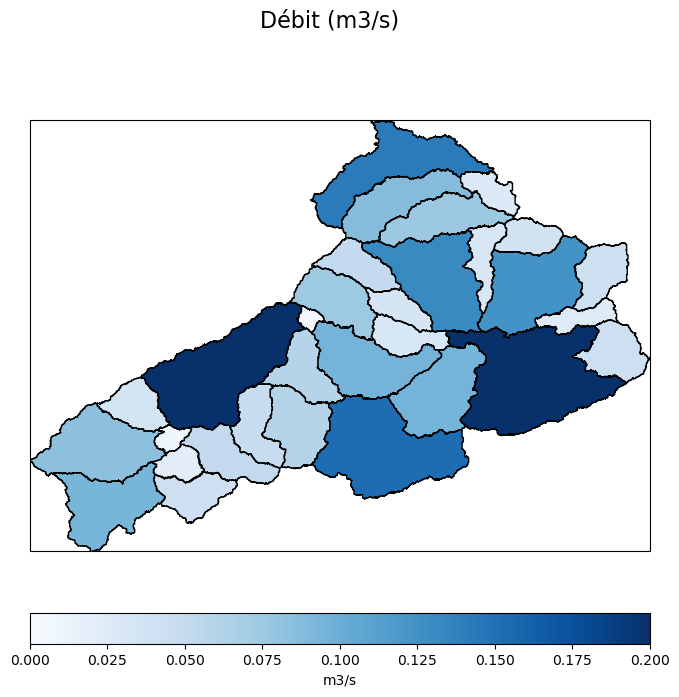

In [55]:
import matplotlib as mpl
file_shape='E:/TUNEZ/GIS/Basin_Acciona_WGS84.shp'
Extent = [8.768407,9.082939,36.764444,36.983116]
fig, ax = plt.subplots(figsize=(8, 8),subplot_kw=dict(projection=ccrs.PlateCarree()))

plot_figure_shp(file_shape,Resultados_Per_ref.iloc[:,0], cmap=mpl.cm.Blues,vmax=0.2,vmin=0,label='m3/s',ax=ax,label_figure='',
                  title='Débit (m3/s)',extent=Extent)

In [56]:
Resultados_Per_ref

,Qmed (m3/s),Sed Med (Ton),Qmax (m3/s) T2,Qmax (m3/s) T5,Qmax (m3/s) T10,Qmax (m3/s) T20,Qmax (m3/s) T50,Qmax (m3/s) T100,Qmax (m3/s) T500
Basin21,0.142767,19.652226,25.125721,29.845726,33.887466,38.392914,45.159870,50.972137,67.205610
Basin24,0.087241,7.522114,22.832851,26.784908,30.154043,33.898285,39.499268,44.292446,57.604473
Basin29,0.038936,0.960297,14.995373,17.599285,19.845932,22.363026,26.161550,29.438936,38.653385
Basin33,0.050949,0.773269,18.847845,21.910658,24.530249,27.443340,31.800787,35.528610,45.874744
Basin35,0.042674,6.206016,15.272288,18.046654,20.430973,23.099281,27.123743,30.594133,40.343277
Basin38,0.031824,90.583675,16.463217,19.407545,21.917559,24.699390,28.849356,32.390630,42.191260
Basin42,0.042549,87.134826,16.963142,20.419330,23.386984,26.695787,31.658510,35.917137,47.811730
Basin44,0.211428,50.935217,33.074146,40.526016,46.995777,54.255740,65.197470,74.610115,101.050170
Basin46,0.094878,11.481483,30.366540,35.697720,40.245777,45.291477,52.844875,59.315200,77.309540
Basin48,0.035986,6.860569,20.711775,24.059315,26.908222,30.063848,34.771860,38.789204,49.900654


In [57]:
Caudal_JUNT7=pd.read_csv('E:/TUNEZ/07_Cambio_Climatico/CAUDAL/Caudal_JUNT7_1979_2005_2.csv',index_col=0, parse_dates=True)
Caudal_SED_JUNT7 = pd.read_csv('E:/TUNEZ/07_Cambio_Climatico/CAUDAL/SED_JUNT7_1979_2005_2.csv',index_col=0, parse_dates=True)

In [58]:
Resultados_Per_ref = pd.DataFrame(index=['OUCHTATA'],columns=['Qmed (m3/s)','Sed Med (Ton)',
                                                                'Qmax (m3/s) T2','Qmax (m3/s) T5','Qmax (m3/s) T10',
                                                                'Qmax (m3/s) T20','Qmax (m3/s) T50','Qmax (m3/s) T100','Qmax (m3/s) T500'])

In [59]:
Resultados_Per_ref.iloc[:,0] = Caudal_JUNT7.mean().values
Resultados_Per_ref.iloc[:,1] = Caudal_SED_JUNT7.mean().values

Resultados_Per_ref.iloc[:,2:] = pd.read_csv('E:/TUNEZ/09_Envio_Resultados/Caudal/Extremal/Hidrogramas_Reg_Extremal_Ouchtata_2.csv',index_col=0, parse_dates=True).max().values

In [60]:
Resultados_Per_ref

,Qmed (m3/s),Sed Med (Ton),Qmax (m3/s) T2,Qmax (m3/s) T5,Qmax (m3/s) T10,Qmax (m3/s) T20,Qmax (m3/s) T50,Qmax (m3/s) T100,Qmax (m3/s) T500
OUCHTATA,2.234178,443.185403,484.0105,588.8045,679.8095,781.37213,932.1295,1061.6906,1424.9684


In [42]:
Resultados_Per_ref

,Qmed (m3/s),Sed Med (Ton),Qmax (m3/s) T2,Qmax (m3/s) T5,Qmax (m3/s) T10,Qmax (m3/s) T20,Qmax (m3/s) T50,Qmax (m3/s) T100,Qmax (m3/s) T500
OUCHTATA,2.12206,488.289204,510.44736,620.94116,716.13916,822.66187,980.93494,1117.0295,1500.8174


In [99]:
Resultados_Per_ref

,Qmed (m3/s),Sed Med (Ton),Qmax (m3/s) T2,Qmax (m3/s) T5,Qmax (m3/s) T10,Qmax (m3/s) T20,Qmax (m3/s) T50,Qmax (m3/s) T100,Qmax (m3/s) T500
OUCHTATA,2.131729,472.779796,468.05,573.805,664.773,767.37,919.962,1051.33,1419.86


In [61]:
Caudal_REACH3=pd.read_csv('E:/TUNEZ/07_Cambio_Climatico/CAUDAL/Caudal_REACH3_1979_2005_2.csv',index_col=0, parse_dates=True)
Caudal_SED_REACH3= pd.read_csv('E:/TUNEZ/07_Cambio_Climatico/CAUDAL/SED_REACH3_1979_2005_2.csv',index_col=0, parse_dates=True)

In [62]:
Resultados_Per_ref = pd.DataFrame(index=["Point d'extraction"],columns=['Qmed (m3/s)','Sed Med (Ton)',
                                                                'Qmax (m3/s) T2','Qmax (m3/s) T5','Qmax (m3/s) T10',
                                                                'Qmax (m3/s) T20','Qmax (m3/s) T50','Qmax (m3/s) T100','Qmax (m3/s) T500'])

In [63]:
Resultados_Per_ref.iloc[:,0] = Caudal_REACH3.mean().values
Resultados_Per_ref.iloc[:,1] = Caudal_SED_REACH3.mean().values

Resultados_Per_ref.iloc[:,2:] = pd.read_csv('E:/TUNEZ/09_Envio_Resultados/Caudal/Extremal/Hidrogramas_Reg_Extremal_Punto_Extraccion_2.csv',index_col=0, parse_dates=True).max().values

In [64]:
Resultados_Per_ref

,Qmed (m3/s),Sed Med (Ton),Qmax (m3/s) T2,Qmax (m3/s) T5,Qmax (m3/s) T10,Qmax (m3/s) T20,Qmax (m3/s) T50,Qmax (m3/s) T100,Qmax (m3/s) T500
Point d'extraction,0.339839,129.969769,123.59311,146.00069,165.07658,186.34756,217.60004,244.66896,318.7684


In [49]:
Resultados_Per_ref

,Qmed (m3/s),Sed Med (Ton),Qmax (m3/s) T2,Qmax (m3/s) T5,Qmax (m3/s) T10,Qmax (m3/s) T20,Qmax (m3/s) T50,Qmax (m3/s) T100,Qmax (m3/s) T500
Point d'extraction,0.317509,115.594098,124.919106,148.25905,168.13689,190.49913,223.3201,252.01683,330.75183


In [22]:
Resultados_Per_ref

,Qmed (m3/s),Sed Med (Ton),Qmax (m3/s) T2,Qmax (m3/s) T5,Qmax (m3/s) T10,Qmax (m3/s) T20,Qmax (m3/s) T50,Qmax (m3/s) T100,Qmax (m3/s) T500
Point d'extraction,0.311405,166.861316,107.706,128.907,146.782,166.55,196.422,221.52,292.095


# Extracción de hidrogramas

In [65]:
Juntions = pd.read_csv('E:/TUNEZ/GIS/Juntions.csv',index_col=0).Name.values

In [66]:
for i in Juntions:
    os.makedirs('E:/TUNEZ/09_Envio_Resultados/Caudal/Extremal/Hidrogramas/'+i+'/',exist_ok=True)
    Caudal_JUNT = pd.DataFrame(index=pd.date_range(start = '2021-01-01', end='2021-01-03',freq = '5min'),columns=[2,5,10,20,50,100,500])
    for j,T in enumerate([2,5,10,20,50,100,500]):
    
        pn = '//'+i.upper()+'/FLOW/01JAN2021/5MIN/RUN:T'+str(T)+'/'
        fid = HecDss.Open(Path_model+'T'+str(T)+'.dss')
        ts = fid.read_ts(pn,window=('2021-01-01','2021-01-04'))
        values = pd.DataFrame(ts.values)
        times = np.array(ts.pytimes)
        Q = pd.DataFrame(index= times, columns = ['flow'])
        Q.loc[:,'flow'] = values.iloc[:,0].values

        Caudal_JUNT.loc[:,T] = values.iloc[:,0].values
    Caudal_JUNT.to_csv('E:/TUNEZ/09_Envio_Resultados/Caudal/Extremal/Hidrogramas/'+i+'/'+'Hidrograma_1979_2005_'+i.upper()+'.csv')